In [1]:
# coding: utf-8
import sys, os
#sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.multi_layer_net_extend import MultiLayerNetExtend

# データの読み込み
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100], output_size=10,
                              use_batchnorm=True)

x_batch = x_train[:1]
t_batch = t_train[:1]

grad_backprop = network.gradient(x_batch, t_batch)
grad_numerical = network.numerical_gradient(x_batch, t_batch)


for key in grad_numerical.keys():
    diff = np.average( np.abs(grad_backprop[key] - grad_numerical[key]) )
    print(key + ":" + str(diff))

W1:0.0
b1:0.0
gamma1:0.0
beta1:0.0
W2:0.0
b2:0.0
gamma2:0.0
beta2:0.05063506786637806
W3:0.0
b3:1.7990402263745597e-07


============== 1/16 ==============
epoch:0 | 0.1 - 0.078
epoch:1 | 0.097 - 0.078


c:\Users\RJC238\Downloads\llmdev\llmdev\Pythonコード・データ\ゼロから作るDeepLearning\deep_learning_from_scratch_master\common\multi_layer_net_extend.py:101: RuntimeWarning: overflow encountered in square
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
c:\Users\RJC238\Downloads\llmdev\llmdev\Pythonコード・データ\ゼロから作るDeepLearning\deep_learning_from_scratch_master\common\multi_layer_net_extend.py:101: RuntimeWarning: invalid value encountered in scalar multiply
  weight_decay += 0.5 * self.weight_decay_lambda * np.sum(W**2)
c:\Users\RJC238\Downloads\llmdev\llmdev\Pythonコード・データ\ゼロから作るDeepLearning\deep_learning_from_scratch_master\common\functions.py:34: RuntimeWarning: invalid value encountered in subtract
  x = x - np.max(x, axis=0)


epoch:2 | 0.097 - 0.101
epoch:3 | 0.097 - 0.152
epoch:4 | 0.097 - 0.177
epoch:5 | 0.097 - 0.198
epoch:6 | 0.097 - 0.203
epoch:7 | 0.097 - 0.227
epoch:8 | 0.097 - 0.26
epoch:9 | 0.097 - 0.266
epoch:10 | 0.097 - 0.294
epoch:11 | 0.097 - 0.3
epoch:12 | 0.097 - 0.321
epoch:13 | 0.097 - 0.338
epoch:14 | 0.097 - 0.345
epoch:15 | 0.097 - 0.365
epoch:16 | 0.097 - 0.383
epoch:17 | 0.097 - 0.397
epoch:18 | 0.097 - 0.41
epoch:19 | 0.097 - 0.422


C:\Users\RJC238\AppData\Local\Temp\ipykernel_4932\1552588355.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


============== 2/16 ==============
epoch:0 | 0.087 - 0.109
epoch:1 | 0.097 - 0.139
epoch:2 | 0.097 - 0.151
epoch:3 | 0.097 - 0.161
epoch:4 | 0.097 - 0.184
epoch:5 | 0.097 - 0.207
epoch:6 | 0.097 - 0.224
epoch:7 | 0.097 - 0.243
epoch:8 | 0.097 - 0.27
epoch:9 | 0.097 - 0.287
epoch:10 | 0.097 - 0.311
epoch:11 | 0.097 - 0.335
epoch:12 | 0.097 - 0.356
epoch:13 | 0.097 - 0.38
epoch:14 | 0.097 - 0.386
epoch:15 | 0.097 - 0.4
epoch:16 | 0.097 - 0.424
epoch:17 | 0.097 - 0.442
epoch:18 | 0.097 - 0.456
epoch:19 | 0.097 - 0.464
============== 3/16 ==============
epoch:0 | 0.112 - 0.131
epoch:1 | 0.314 - 0.164
epoch:2 | 0.457 - 0.215
epoch:3 | 0.535 - 0.258
epoch:4 | 0.625 - 0.305
epoch:5 | 0.683 - 0.349
epoch:6 | 0.74 - 0.38
epoch:7 | 0.781 - 0.406
epoch:8 | 0.805 - 0.435
epoch:9 | 0.832 - 0.455
epoch:10 | 0.863 - 0.487
epoch:11 | 0.899 - 0.521
epoch:12 | 0.908 - 0.535
epoch:13 | 0.929 - 0.551
epoch:14 | 0.93 - 0.586
epoch:15 | 0.949 - 0.605
epoch:16 | 0.952 - 0.635
epoch:17 | 0.959 - 0.637
epoch:1

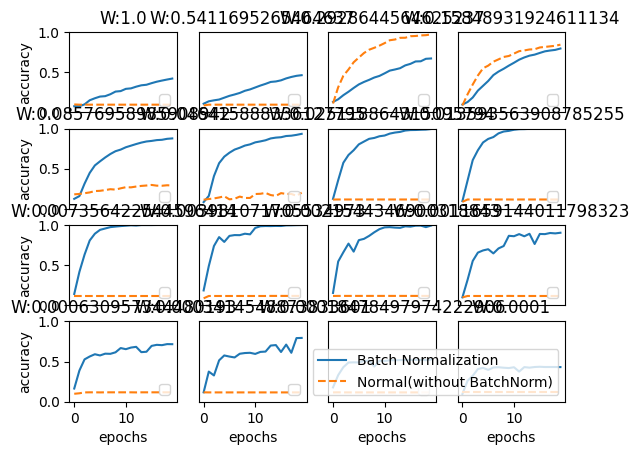

In [2]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.multi_layer_net_extend import MultiLayerNetExtend
from deep_learning_from_scratch_master.common.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 学習データを削減
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 3.グラフの描画==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    
    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')
    
plt.show()

val acc:0.12 | lr:1.3232632335983822e-06, weight decay:3.696161681299594e-08
val acc:0.73 | lr:0.006825479145966606, weight decay:1.5708078933924911e-07
val acc:0.06 | lr:2.238656249579275e-06, weight decay:3.391502577092947e-07
val acc:0.06 | lr:0.00033272224442755586, weight decay:3.1979603966404626e-05
val acc:0.4 | lr:0.0029084692412214845, weight decay:2.509494198413196e-08
val acc:0.08 | lr:1.9544016877119957e-06, weight decay:2.716269415509301e-08
val acc:0.11 | lr:0.0002549995975200284, weight decay:1.7382565576657334e-07
val acc:0.12 | lr:8.901350764457383e-05, weight decay:5.210220506953457e-08
val acc:0.07 | lr:1.0325887612654536e-05, weight decay:4.458945262335869e-06
val acc:0.1 | lr:0.000388055874284441, weight decay:3.6987672739529817e-07
val acc:0.07 | lr:6.587210003363426e-05, weight decay:3.636750235626796e-07
val acc:0.08 | lr:3.4689361867485934e-06, weight decay:6.182869179538866e-06
val acc:0.1 | lr:8.941226023959487e-06, weight decay:6.520149989575195e-05
val acc:

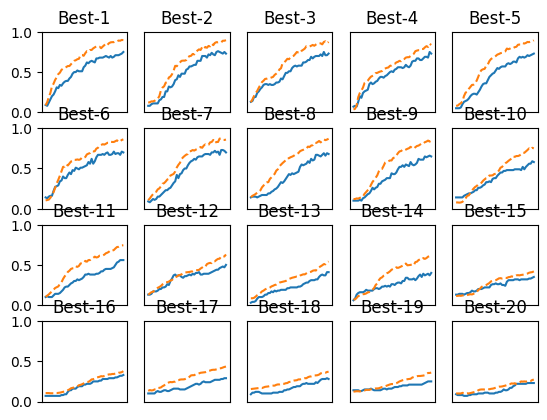

In [3]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.multi_layer_net import MultiLayerNet
from deep_learning_from_scratch_master.common.util import shuffle_dataset
from deep_learning_from_scratch_master.common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 高速化のため訓練データの削減
x_train = x_train[:500]
t_train = t_train[:500]

# 検証データの分離
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list


# ハイパーパラメータのランダム探索======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 探索したハイパーパラメータの範囲を指定===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

# グラフの描画========================================================
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.show()


===========iteration:0===========
SGD:2.4439369005893496
Momentum:2.47418608812132
AdaGrad:2.2972115397294863
Adam:2.183139076915604
===========iteration:100===========
SGD:1.807619919051945
Momentum:0.2767059210138988
AdaGrad:0.11751209044573038
Adam:0.19827217460427646
===========iteration:200===========
SGD:0.9170902787187001
Momentum:0.272633896805861
AdaGrad:0.14000174698662626
Adam:0.23870320268731207
===========iteration:300===========
SGD:0.5172586141080854
Momentum:0.1583634114999823
AdaGrad:0.08651900777540528
Adam:0.1182167336017233
===========iteration:400===========
SGD:0.40763435404005344
Momentum:0.14857868199080088
AdaGrad:0.05182381602538132
Adam:0.10783296792661955
===========iteration:500===========
SGD:0.42829144090608057
Momentum:0.15117614013642966
AdaGrad:0.09925076598733859
Adam:0.10970274173363695
===========iteration:600===========
SGD:0.39194295419302283
Momentum:0.08294960583349952
AdaGrad:0.03476589547475821
Adam:0.06673238560381678
===========iteration:700

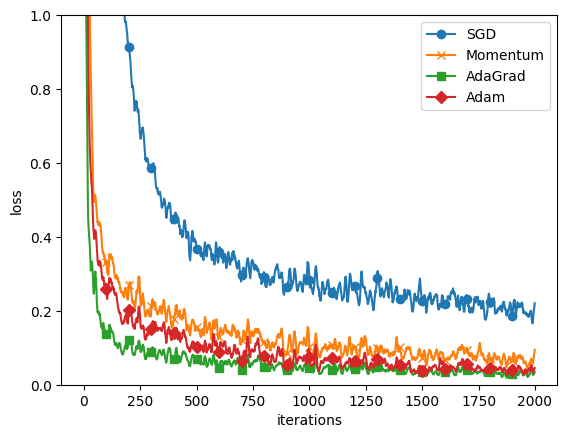

In [4]:
# coding: utf-8
import os
import sys
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import matplotlib.pyplot as plt
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.util import smooth_curve
from deep_learning_from_scratch_master.common.multi_layer_net import MultiLayerNet
from deep_learning_from_scratch_master.common.optimizer import *


# 0:MNISTデータの読み込み==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1:実験の設定==========
optimizers = {}
optimizers['SGD'] = SGD()
optimizers['Momentum'] = Momentum()
optimizers['AdaGrad'] = AdaGrad()
optimizers['Adam'] = Adam()
#optimizers['RMSprop'] = RMSprop()

networks = {}
train_loss = {}
for key in optimizers.keys():
    networks[key] = MultiLayerNet(
        input_size=784, hidden_size_list=[100, 100, 100, 100],
        output_size=10)
    train_loss[key] = []    


# 2:訓練の開始==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in optimizers.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizers[key].update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print( "===========" + "iteration:" + str(i) + "===========")
        for key in optimizers.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3.グラフの描画==========
markers = {"SGD": "o", "Momentum": "x", "AdaGrad": "s", "Adam": "D"}
x = np.arange(max_iterations)
for key in optimizers.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 1)
plt.legend()
plt.show()


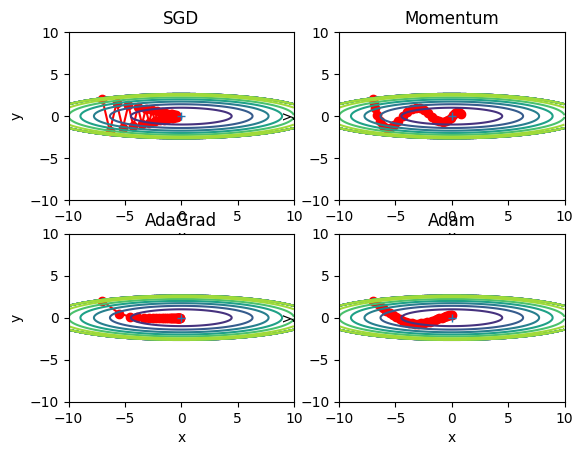

In [5]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from deep_learning_from_scratch_master.common.optimizer import *


def f(x, y):
    return x**2 / 20.0 + y**2


def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0


optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)
optimizers["Momentum"] = Momentum(lr=0.1)
optimizers["AdaGrad"] = AdaGrad(lr=1.5)
optimizers["Adam"] = Adam(lr=0.3)

idx = 1

for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):
        x_history.append(params['x'])
        y_history.append(params['y'])
        
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    

    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    
    X, Y = np.meshgrid(x, y) 
    Z = f(X, Y)
    
    # for simple contour line  
    mask = Z > 7
    Z[mask] = 0
    
    # plot 
    plt.subplot(2, 2, idx)
    idx += 1
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.contour(X, Y, Z)
    plt.ylim(-10, 10)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    #colorbar()
    #spring()
    plt.title(key)
    plt.xlabel("x")
    plt.ylabel("y")
    
plt.show()

===========iteration:0===========
std=0.01:2.302509914017235
Xavier:2.301921080529012
He:2.4622391678303726
===========iteration:100===========
std=0.01:2.3027496975863033
Xavier:2.233686103491264
He:1.3934770280598854
===========iteration:200===========
std=0.01:2.300946275543155
Xavier:2.046522236905865
He:0.6654400781863457
===========iteration:300===========
std=0.01:2.3021952553608043
Xavier:1.6314894220308216
He:0.5479706134829277
===========iteration:400===========
std=0.01:2.2992342793171576
Xavier:1.0732290385294139
He:0.3026382597666072
===========iteration:500===========
std=0.01:2.3020289415555144
Xavier:0.8300191798218386
He:0.39018624466262936
===========iteration:600===========
std=0.01:2.2993303058216537
Xavier:0.5785893521448353
He:0.3068660836542459
===========iteration:700===========
std=0.01:2.3052909914574267
Xavier:0.643338114617393
He:0.36400774223729393
===========iteration:800===========
std=0.01:2.3049024422951856
Xavier:0.600413689580966
He:0.4488896280126063

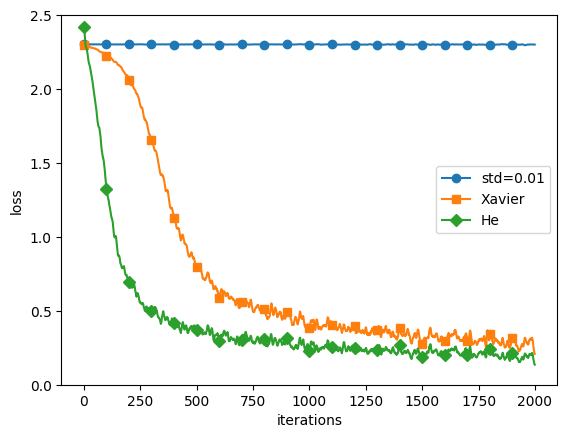

In [6]:
# coding: utf-8
import os
import sys

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.util import smooth_curve
from deep_learning_from_scratch_master.common.multi_layer_net import MultiLayerNet
from deep_learning_from_scratch_master.common.optimizer import SGD


# 0:MNISTデータの読み込み==========
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000


# 1:実験の設定==========
weight_init_types = {'std=0.01': 0.01, 'Xavier': 'sigmoid', 'He': 'relu'}
optimizer = SGD(lr=0.01)

networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []


# 2:訓練の開始==========
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    
    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
    
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)
    
    if i % 100 == 0:
        print("===========" + "iteration:" + str(i) + "===========")
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ":" + str(loss))


# 3.グラフの描画==========
markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

============== 1/16 ==============
epoch:0 | 0.1 - 0.102
epoch:1 | 0.097 - 0.107
epoch:2 | 0.097 - 0.128
epoch:3 | 0.097 - 0.175
epoch:4 | 0.097 - 0.207
epoch:5 | 0.097 - 0.226
epoch:6 | 0.097 - 0.253
epoch:7 | 0.097 - 0.271
epoch:8 | 0.097 - 0.295
epoch:9 | 0.097 - 0.314
epoch:10 | 0.097 - 0.327
epoch:11 | 0.097 - 0.342
epoch:12 | 0.097 - 0.352
epoch:13 | 0.097 - 0.364
epoch:14 | 0.097 - 0.38
epoch:15 | 0.097 - 0.398
epoch:16 | 0.097 - 0.411
epoch:17 | 0.097 - 0.413
epoch:18 | 0.097 - 0.419
epoch:19 | 0.097 - 0.441
============== 2/16 ==============
epoch:0 | 0.097 - 0.099


C:\Users\RJC238\AppData\Local\Temp\ipykernel_4932\1552588355.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


epoch:1 | 0.097 - 0.091
epoch:2 | 0.097 - 0.102
epoch:3 | 0.097 - 0.141
epoch:4 | 0.097 - 0.171
epoch:5 | 0.097 - 0.197
epoch:6 | 0.097 - 0.214
epoch:7 | 0.097 - 0.233
epoch:8 | 0.097 - 0.257
epoch:9 | 0.097 - 0.264
epoch:10 | 0.097 - 0.288
epoch:11 | 0.097 - 0.305
epoch:12 | 0.097 - 0.324
epoch:13 | 0.097 - 0.335
epoch:14 | 0.097 - 0.359
epoch:15 | 0.097 - 0.375
epoch:16 | 0.097 - 0.401
epoch:17 | 0.097 - 0.415
epoch:18 | 0.097 - 0.431
epoch:19 | 0.097 - 0.443
============== 3/16 ==============
epoch:0 | 0.114 - 0.094
epoch:1 | 0.396 - 0.088
epoch:2 | 0.552 - 0.111
epoch:3 | 0.648 - 0.139
epoch:4 | 0.722 - 0.179
epoch:5 | 0.784 - 0.229
epoch:6 | 0.828 - 0.262
epoch:7 | 0.866 - 0.292
epoch:8 | 0.894 - 0.339
epoch:9 | 0.93 - 0.359
epoch:10 | 0.944 - 0.388
epoch:11 | 0.947 - 0.429
epoch:12 | 0.967 - 0.453
epoch:13 | 0.971 - 0.474
epoch:14 | 0.976 - 0.5
epoch:15 | 0.983 - 0.525
epoch:16 | 0.982 - 0.535
epoch:17 | 0.987 - 0.562
epoch:18 | 0.989 - 0.578
epoch:19 | 0.992 - 0.6
==============

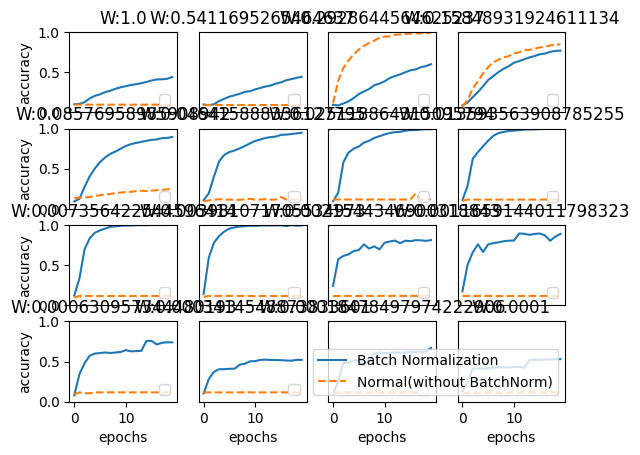

In [7]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.multi_layer_net_extend import MultiLayerNetExtend
from deep_learning_from_scratch_master.common.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 学習データを削減
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10, 
                                    weight_init_std=weight_init_std, use_batchnorm=True)
    network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100], output_size=10,
                                weight_init_std=weight_init_std)
    optimizer = SGD(lr=learning_rate)
    
    train_acc_list = []
    bn_train_acc_list = []
    
    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0
    
    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]
    
        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)
    
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)
    
            print("epoch:" + str(epoch_cnt) + " | " + str(train_acc) + " - " + str(bn_train_acc))
    
            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break
                
    return train_acc_list, bn_train_acc_list


# 3.グラフの描画==========
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

for i, w in enumerate(weight_scale_list):
    print( "============== " + str(i+1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)
    
    plt.subplot(4,4,i+1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label='Batch Normalization', markevery=2)
        plt.plot(x, train_acc_list, linestyle = "--", label='Normal(without BatchNorm)', markevery=2)
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc='lower right')
    
plt.show()

epoch:0, train acc:0.09333333333333334, test acc:0.1044
epoch:1, train acc:0.12333333333333334, test acc:0.1175
epoch:2, train acc:0.14333333333333334, test acc:0.1375
epoch:3, train acc:0.16, test acc:0.153
epoch:4, train acc:0.18666666666666668, test acc:0.1675
epoch:5, train acc:0.19333333333333333, test acc:0.1829
epoch:6, train acc:0.21, test acc:0.1943
epoch:7, train acc:0.22666666666666666, test acc:0.2039
epoch:8, train acc:0.23333333333333334, test acc:0.2199
epoch:9, train acc:0.26, test acc:0.2306
epoch:10, train acc:0.2633333333333333, test acc:0.2319
epoch:11, train acc:0.27666666666666667, test acc:0.2375
epoch:12, train acc:0.2866666666666667, test acc:0.2478
epoch:13, train acc:0.2966666666666667, test acc:0.2603
epoch:14, train acc:0.31, test acc:0.2693
epoch:15, train acc:0.33, test acc:0.2735
epoch:16, train acc:0.33, test acc:0.2838
epoch:17, train acc:0.33666666666666667, test acc:0.2874
epoch:18, train acc:0.36333333333333334, test acc:0.3006
epoch:19, train acc:0

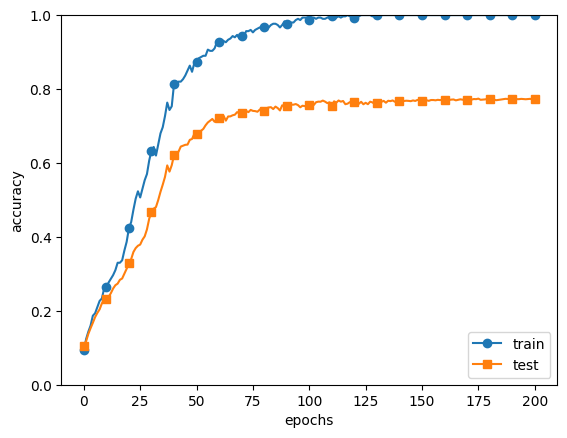

In [10]:
# coding: utf-8
import os
import sys

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.multi_layer_net import MultiLayerNet
from deep_learning_from_scratch_master.common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（荷重減衰）の設定 =======================
weight_decay_lambda = 0 # weight decayを使用しない場合
#weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 3.グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

epoch:0, train acc:0.1, test acc:0.0966
epoch:1, train acc:0.10333333333333333, test acc:0.0969
epoch:2, train acc:0.12333333333333334, test acc:0.1086
epoch:3, train acc:0.16, test acc:0.1257
epoch:4, train acc:0.20666666666666667, test acc:0.1536
epoch:5, train acc:0.24666666666666667, test acc:0.1696
epoch:6, train acc:0.28, test acc:0.1999
epoch:7, train acc:0.31333333333333335, test acc:0.221
epoch:8, train acc:0.33666666666666667, test acc:0.2427
epoch:9, train acc:0.37, test acc:0.2639
epoch:10, train acc:0.4033333333333333, test acc:0.284
epoch:11, train acc:0.41333333333333333, test acc:0.2984
epoch:12, train acc:0.43, test acc:0.315
epoch:13, train acc:0.47333333333333333, test acc:0.34
epoch:14, train acc:0.4866666666666667, test acc:0.3471
epoch:15, train acc:0.5066666666666667, test acc:0.3651
epoch:16, train acc:0.5366666666666666, test acc:0.3826
epoch:17, train acc:0.56, test acc:0.3967
epoch:18, train acc:0.5533333333333333, test acc:0.4011
epoch:19, train acc:0.553333

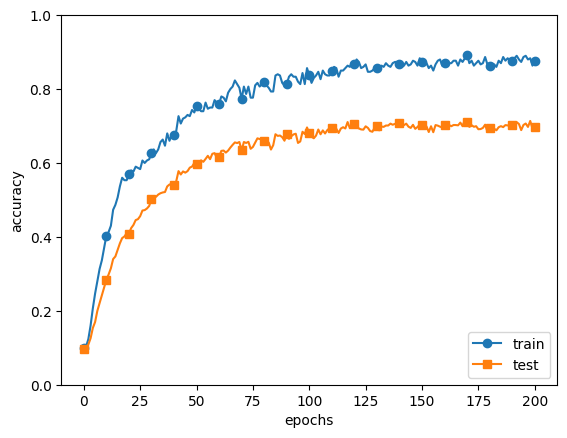

In [11]:
# coding: utf-8
import os
import sys

sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.multi_layer_net import MultiLayerNet
from deep_learning_from_scratch_master.common.optimizer import SGD

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# weight decay（荷重減衰）の設定 =======================
#weight_decay_lambda = 0 # weight decayを使用しない場合
weight_decay_lambda = 0.1
# ====================================================

network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100], output_size=10,
                        weight_decay_lambda=weight_decay_lambda)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(1000000000):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break


# 3.グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

train loss:2.303335293570518
=== epoch:1, train acc:0.05333333333333334, test acc:0.0487 ===
train loss:2.307097677882836
train loss:2.288367743468826
train loss:2.318085143176983
=== epoch:2, train acc:0.05333333333333334, test acc:0.0497 ===
train loss:2.301018747264619
train loss:2.314059721863296
train loss:2.295729948909296
=== epoch:3, train acc:0.05333333333333334, test acc:0.05 ===
train loss:2.3179536287413667
train loss:2.299194877668894
train loss:2.311776538475547
=== epoch:4, train acc:0.05, test acc:0.0506 ===
train loss:2.306705451479018
train loss:2.3043851134966857
train loss:2.2922602283435327
=== epoch:5, train acc:0.05, test acc:0.0501 ===
train loss:2.3029905080395023
train loss:2.3150290791738657
train loss:2.306285775745864
=== epoch:6, train acc:0.05, test acc:0.0503 ===
train loss:2.306793249130112
train loss:2.3022612909077345
train loss:2.29694823281423
=== epoch:7, train acc:0.05, test acc:0.0516 ===
train loss:2.304948610249782
train loss:2.305311133866984


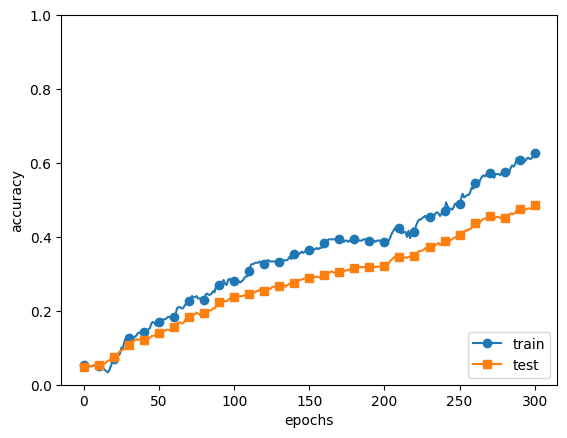

In [12]:
# coding: utf-8
import os
import sys
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.multi_layer_net_extend import MultiLayerNetExtend
from deep_learning_from_scratch_master.common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 過学習を再現するために、学習データを削減
x_train = x_train[:300]
t_train = t_train[:300]

# Dropuoutの有無、割り合いの設定 ========================
use_dropout = True  # Dropoutなしのときの場合はFalseに
dropout_ratio = 0.2
# ====================================================

network = MultiLayerNetExtend(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                              output_size=10, use_dropout=use_dropout, dropout_ration=dropout_ratio)
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=301, mini_batch_size=100,
                  optimizer='sgd', optimizer_param={'lr': 0.01}, verbose=True)
trainer.train()

train_acc_list, test_acc_list = trainer.train_acc_list, trainer.test_acc_list

# グラフの描画==========
markers = {'train': 'o', 'test': 's'}
x = np.arange(len(train_acc_list))
plt.plot(x, train_acc_list, marker='o', label='train', markevery=10)
plt.plot(x, test_acc_list, marker='s', label='test', markevery=10)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()

val acc:0.05 | lr:5.3293275226034874e-05, weight decay:2.1773083052031933e-05
val acc:0.05 | lr:6.12997303381825e-05, weight decay:1.9510222680388148e-07
val acc:0.12 | lr:1.4176894950663025e-05, weight decay:6.538165914562523e-07
val acc:0.12 | lr:8.075583839971643e-06, weight decay:4.281584686453491e-07
val acc:0.13 | lr:0.00011317939012227664, weight decay:3.6043038594881726e-05
val acc:0.14 | lr:6.61322778125239e-05, weight decay:3.36737895428092e-05
val acc:0.16 | lr:6.610502380821253e-05, weight decay:2.480735587117727e-08
val acc:0.1 | lr:9.014253696959099e-05, weight decay:2.049868425631083e-07
val acc:0.14 | lr:1.6142444071303e-06, weight decay:8.231341055023809e-08
val acc:0.1 | lr:0.00017542742910198157, weight decay:1.893727763880838e-07
val acc:0.12 | lr:0.00037088080707002846, weight decay:2.045476322299813e-08
val acc:0.59 | lr:0.0035970414085159217, weight decay:8.811555039181764e-08
val acc:0.06 | lr:0.0001002797387452553, weight decay:4.13739186642395e-05
val acc:0.43

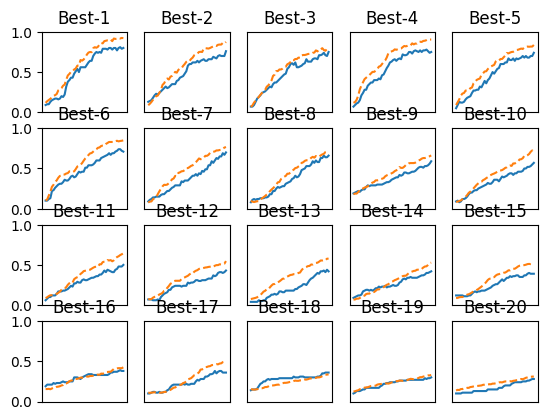

In [13]:
# coding: utf-8
import sys, os
sys.path.append(os.pardir)  # 親ディレクトリのファイルをインポートするための設定
import numpy as np
import matplotlib.pyplot as plt
from deep_learning_from_scratch_master.dataset.mnist import load_mnist
from deep_learning_from_scratch_master.common.multi_layer_net import MultiLayerNet
from deep_learning_from_scratch_master.common.util import shuffle_dataset
from deep_learning_from_scratch_master.common.trainer import Trainer

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

# 高速化のため訓練データの削減
x_train = x_train[:500]
t_train = t_train[:500]

# 検証データの分離
validation_rate = 0.20
validation_num = int(x_train.shape[0] * validation_rate)
x_train, t_train = shuffle_dataset(x_train, t_train)
x_val = x_train[:validation_num]
t_val = t_train[:validation_num]
x_train = x_train[validation_num:]
t_train = t_train[validation_num:]


def __train(lr, weight_decay, epocs=50):
    network = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100, 100, 100],
                            output_size=10, weight_decay_lambda=weight_decay)
    trainer = Trainer(network, x_train, t_train, x_val, t_val,
                      epochs=epocs, mini_batch_size=100,
                      optimizer='sgd', optimizer_param={'lr': lr}, verbose=False)
    trainer.train()

    return trainer.test_acc_list, trainer.train_acc_list


# ハイパーパラメータのランダム探索======================================
optimization_trial = 100
results_val = {}
results_train = {}
for _ in range(optimization_trial):
    # 探索したハイパーパラメータの範囲を指定===============
    weight_decay = 10 ** np.random.uniform(-8, -4)
    lr = 10 ** np.random.uniform(-6, -2)
    # ================================================

    val_acc_list, train_acc_list = __train(lr, weight_decay)
    print("val acc:" + str(val_acc_list[-1]) + " | lr:" + str(lr) + ", weight decay:" + str(weight_decay))
    key = "lr:" + str(lr) + ", weight decay:" + str(weight_decay)
    results_val[key] = val_acc_list
    results_train[key] = train_acc_list

# グラフの描画========================================================
print("=========== Hyper-Parameter Optimization Result ===========")
graph_draw_num = 20
col_num = 5
row_num = int(np.ceil(graph_draw_num / col_num))
i = 0

for key, val_acc_list in sorted(results_val.items(), key=lambda x:x[1][-1], reverse=True):
    print("Best-" + str(i+1) + "(val acc:" + str(val_acc_list[-1]) + ") | " + key)

    plt.subplot(row_num, col_num, i+1)
    plt.title("Best-" + str(i+1))
    plt.ylim(0.0, 1.0)
    if i % 5: plt.yticks([])
    plt.xticks([])
    x = np.arange(len(val_acc_list))
    plt.plot(x, val_acc_list)
    plt.plot(x, results_train[key], "--")
    i += 1

    if i >= graph_draw_num:
        break

plt.show()
